# Refined Stage 3J - accuracy against inference cost (RQ3, objective O5)

RQ3 asks which combinations give

> "the most favourable **accuracy–inference-cost trade-off** for representative energy
> forecasting scenarios"

and objective O5 asks for a selection matrix *"with inference cost"*.

**Stage 3F does not answer this.** It ranks configurations by median relMAE and marks
`deployable = median_relMAE < 1.0`; `infer_sec` is printed but never enters the decision. A
ranking on accuracy alone answers a different question from the one RQ3 asks.

This notebook supplies the missing half. It runs no models — every timing was already recorded
per forecast in the sweep files.

> **Two corrections applied here.**
>
> 1. **De-duplication.** 3F concatenates Stage 2, 3B, 3C and 3D, which genuinely overlap —
>    12.7% of the pooled window-model keys appear in more than one file. That inflates the
>    `n` column and double-weights the overlapping windows. Windows are de-duplicated on their
>    full key before aggregation here.
> 2. **Timing is relative, not absolute.** These are single-series, unbatched, same-machine
>    measurements. They support "model A costs ~k× model B on this hardware"; they do not
>    support a throughput claim for a production deployment.

In [1]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) -- restart the kernel and Run All")
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
GRAN_C  = {"native": "#dc2626", "1h": "#2563eb", "1D": "#16a34a"}
print(f"common module {C.__version__} from {C.__file__}")

def load_clean(path):
    """Scored, non-degenerate windows with a usable relMAE."""
    d = pd.read_csv(path)
    n0 = len(d)
    d = d[~d.degenerate].dropna(subset=["relMAE"])
    d = d[d.relMAE > 0]                      # log-scale analysis needs strictly positive
    print(f"{path}: {n0:,} rows -> {len(d):,} usable "
          f"({100*(n0-len(d))/n0:.1f}% dropped: degenerate or no benchmark)")
    return d

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [2]:
FILES = ["refined_stage2_results.csv", "refined_stage3b_context_sweep.csv",
         "refined_stage3c_horizon_sweep.csv", "refined_stage3d_fixed_lead_time.csv"]
KEY = ["etype", "gran", "series_id", "origin_index",
       "context_steps", "horizon_steps", "model"]

parts = []
for f in FILES:
    if os.path.exists(f):
        d = pd.read_csv(f); d["source"] = f
        parts.append(d); print(f"{len(d):>7,} rows <- {f}")
assert parts, "no result files found"
raw = pd.concat(parts, ignore_index=True)

dups = raw.duplicated(subset=KEY, keep=False).sum()
allres = raw.drop_duplicates(subset=KEY, keep="first")
print(f"\n{len(raw):,} pooled rows | {dups:,} carried a duplicated window key "
      f"({100*dups/len(raw):.1f}%) -> {len(allres):,} unique window-model results")

allres = allres[~allres.degenerate].dropna(subset=["relMAE"])
print(f"{len(allres):,} usable after removing degenerate windows and missing benchmarks")

  1,350 rows <- refined_stage2_results.csv
 24,300 rows <- refined_stage3b_context_sweep.csv
 23,400 rows <- refined_stage3c_horizon_sweep.csv
 34,890 rows <- refined_stage3d_fixed_lead_time.csv

83,940 pooled rows | 11,070 carried a duplicated window key (13.2%) -> 78,180 unique window-model results
61,485 usable after removing degenerate windows and missing benchmarks


## 1. What inference actually costs

Before any trade-off, the size of the cost difference has to be established. If all three
models cost the same, RQ3 collapses back into an accuracy question.

         median    mean      std   size  vs_cheapest  forecasts_per_min
model                                                                  
chronos  0.0172  0.0299   0.0438  20495          1.0             3486.0
moirai   0.0316  0.0416   0.0271  20495          1.8             1901.0
timesfm  0.2717  0.5416  23.6902  20495         15.8              221.0

cost against context length (does the gap widen with more history?)
model          chronos  moirai  timesfm
context_steps                          
40              0.0161  0.0326   0.3297
48              0.0159  0.0341   0.2474
62              0.0222  0.0235   0.3997
125             0.0933  0.0397   0.4262
128             0.0161  0.0278   0.2639
144             0.0158  0.0336   0.2408
162             0.0330  0.0341   0.3723
168             0.0162  0.0355   0.2995
225             0.0354  0.0352   0.3696
256             0.0180  0.0293   0.2717
336             0.0156  0.0319   0.3561
512             0.0358  0.0253   0.2264
960        

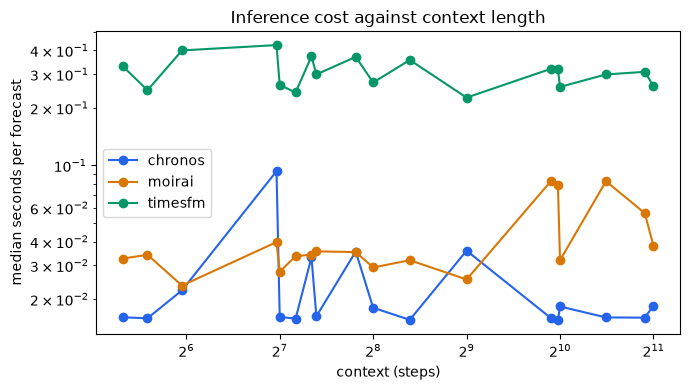

In [3]:
cost = allres.groupby("model").infer_sec.agg(["median", "mean", "std", "size"])
cost["vs_cheapest"] = (cost["median"] / cost["median"].min()).round(1)
cost["forecasts_per_min"] = (60 / cost["median"]).round(0)
print(cost.round(4).to_string())

print("\ncost against context length (does the gap widen with more history?)")
ct = allres.pivot_table(index="context_steps", columns="model",
                        values="infer_sec", aggfunc="median")
print(ct.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
for m, g in allres.groupby("model"):
    y = g.groupby("context_steps").infer_sec.median()
    ax.plot(y.index, y.values, marker="o", color=PALETTE.get(m), label=m)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("context (steps)"); ax.set_ylabel("median seconds per forecast")
ax.set_title("Inference cost against context length")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Every configuration, scored on both axes

`worst_series_relMAE` is the worst *series* by its own median — not the worst window. relMAE is
unbounded when the seasonal-naive denominator approaches zero, so a maximum over windows is an
outlier detector rather than a risk measure. `p90_relMAE` is kept as a bounded tail statistic.

In [4]:
grp = allres.groupby(["etype", "gran", "gran_label", "context_steps", "horizon_steps", "model"])
cfg = grp.agg(median_relMAE=("relMAE", "median"),
              p90_relMAE=("relMAE", lambda s: s.quantile(.90)),
              infer_sec=("infer_sec", "median"),
              n=("relMAE", "size")).reset_index()
cfg["worst_series_relMAE"] = grp.apply(
    lambda g: g.groupby("series_id")["relMAE"].median().max()).values
cfg["step_min"] = [C.step_minutes(e, g) for e, g in zip(cfg.etype, cfg.gran)]
cfg["history"]  = [C.human_duration(c*d) for c, d in zip(cfg.context_steps, cfg.step_min)]
cfg["lead"]     = [C.human_duration(h*d) for h, d in zip(cfg.horizon_steps, cfg.step_min)]
cfg["beats_benchmark"] = cfg.median_relMAE < 1.0
print(f"{len(cfg)} configurations | {int(cfg.beats_benchmark.sum())} beat the "
      f"seasonal-naive benchmark on the median")
cfg.to_csv("refined_stage3j_configurations_with_cost.csv", index=False)

333 configurations | 216 beat the seasonal-naive benchmark on the median


## 3. The Pareto frontier

A configuration is **dominated** when another is both faster *and* more accurate. Dominated
configurations can be discarded regardless of how the trade-off is weighted — no rational
operator picks one. What survives is the frontier, and the choice along it is a genuine
judgement about how much accuracy a second of compute is worth.

In [5]:
def frontier(g):
    g = g.sort_values(["infer_sec", "median_relMAE"])
    best, keep = np.inf, []
    for r in g.itertuples():
        if r.median_relMAE < best:
            keep.append(r.Index); best = r.median_relMAE
    return g.loc[keep]

front = pd.concat([frontier(g) for _, g in cfg.groupby("etype")])
cfg["pareto"] = cfg.index.isin(front.index)

for et, g in cfg.groupby("etype"):
    f = g[g.pareto].sort_values("infer_sec")
    print(f"\n=== {et}: {len(f)} of {len(g)} configurations are Pareto-optimal "
          f"({len(g)-len(f)} dominated) ===")
    print(f[["gran_label", "history", "lead", "model", "median_relMAE",
             "worst_series_relMAE", "p90_relMAE", "infer_sec"]].round(3).to_string(index=False))
    print(f"   frontier model mix: {f.model.value_counts().to_dict()}")
cfg.to_csv("refined_stage3j_configurations_with_cost.csv", index=False)


=== load: 7 of 132 configurations are Pareto-optimal (125 dominated) ===
      gran_label  history   lead   model  median_relMAE  worst_series_relMAE  p90_relMAE  infer_sec
minutes (native)    7.0 d  1.0 h chronos          0.424                0.609       2.642      0.015
          hourly    7.0 d  1.0 h chronos          0.331                0.555       3.306      0.016
          hourly   40.0 d  1.0 h chronos          0.331                0.487       2.365      0.016
minutes (native)   40.0 d  1.0 h chronos          0.317                0.532       1.879      0.016
          hourly    7.0 d  1.0 h timesfm          0.299                0.501       2.358      0.241
           daily 2048.0 d 24.0 d timesfm          0.278                0.299       0.488      0.259
minutes (native)   40.0 d  1.0 h timesfm          0.227                0.438       1.265      0.308
   frontier model mix: {'chronos': 4, 'timesfm': 3}

=== solar: 4 of 105 configurations are Pareto-optimal (101 dominated) ===

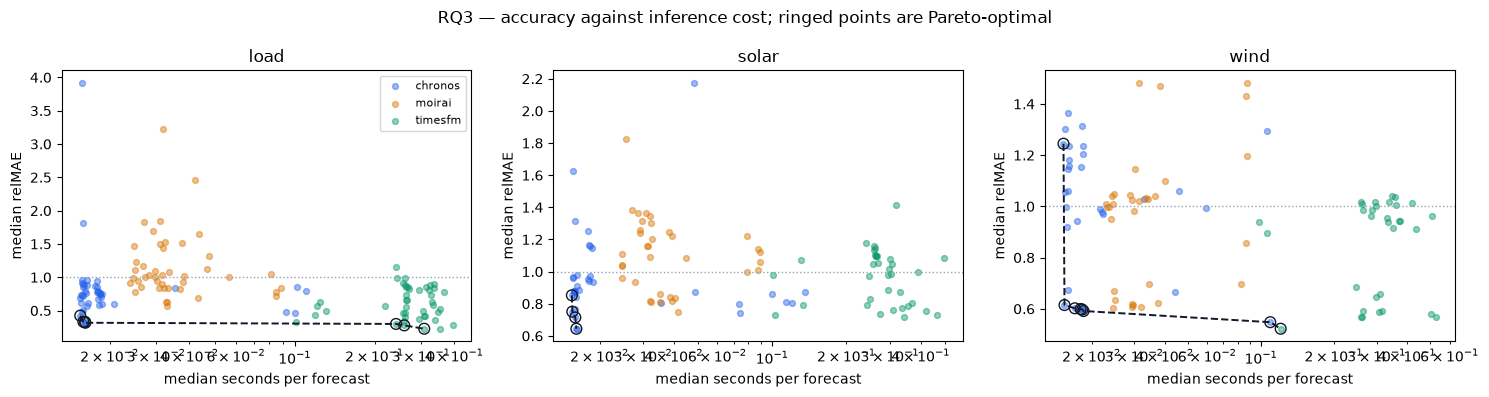

In [6]:
ets = sorted(cfg.etype.unique())
fig, axes = plt.subplots(1, len(ets), figsize=(5*len(ets), 4), squeeze=False)
for ax, et in zip(axes[0], ets):
    g = cfg[cfg.etype == et]
    for m, gg in g.groupby("model"):
        ax.scatter(gg.infer_sec, gg.median_relMAE, s=18, alpha=0.45,
                   color=PALETTE.get(m), label=m)
    f = g[g.pareto].sort_values("infer_sec")
    ax.plot(f.infer_sec, f.median_relMAE, color="#111827", lw=1.4, ls="--", zorder=5)
    ax.scatter(f.infer_sec, f.median_relMAE, s=60, facecolors="none",
               edgecolors="#111827", zorder=6)
    ax.axhline(1.0, color="#94a3b8", ls=":", lw=1)
    ax.set_xscale("log"); ax.set_title(et)
    ax.set_xlabel("median seconds per forecast"); ax.set_ylabel("median relMAE")
axes[0][0].legend(fontsize=8)
plt.suptitle("RQ3 — accuracy against inference cost; ringed points are Pareto-optimal")
plt.tight_layout(); plt.show()

## 4. Representative operational scenarios

RQ3 asks about *scenarios*, not configurations in the abstract. Lead time is what defines an
energy forecasting scenario operationally — balancing acts minutes ahead, dispatch hours ahead,
scheduling a day ahead — so scenarios are defined by lead-time band and the frontier is read
within each.

For every scenario the table gives the cheapest configuration that beats the benchmark, the
most accurate one, and **what the accuracy actually costs**: the extra seconds per forecast per
unit of relMAE gained. That ratio is the answer RQ3 is asking for.

In [7]:
BANDS = [(0, 60, "intra-hour balancing (<= 1 h)"),
         (60, 360, "short-term dispatch (1-6 h)"),
         (360, 1440, "same-day scheduling (6-24 h)"),
         (1440, np.inf, "day-ahead and beyond (> 24 h)")]

cfg["lead_min"] = cfg.horizon_steps * cfg.step_min
def band(x):
    for lo, hi, nm in BANDS:
        if lo < x <= hi: return nm
    return "other"
cfg["scenario"] = cfg.lead_min.map(band)

rows = []
for (et, sc), g in cfg.groupby(["etype", "scenario"]):
    ok = g[g.beats_benchmark]
    if ok.empty:
        rows.append({"etype": et, "scenario": sc, "n_cfg": len(g),
                     "verdict": "NO configuration beats the benchmark"}); continue
    cheap = ok.loc[ok.infer_sec.idxmin()]
    acc   = ok.loc[ok.median_relMAE.idxmin()]
    d_acc = cheap.median_relMAE - acc.median_relMAE
    d_cost = acc.infer_sec - cheap.infer_sec
    rows.append({
        "etype": et, "scenario": sc, "n_cfg": len(g), "n_beating": len(ok),
        "cheapest": f"{cheap.model}/{cheap.gran_label}", "cheap_relMAE": cheap.median_relMAE,
        "cheap_sec": cheap.infer_sec,
        "most_accurate": f"{acc.model}/{acc.gran_label}", "acc_relMAE": acc.median_relMAE,
        "acc_sec": acc.infer_sec,
        "relMAE_gained": d_acc, "extra_sec": d_cost,
        "sec_per_0.01_relMAE": (d_cost / (d_acc*100)) if d_acc > 1e-9 else np.nan,
        "verdict": "same configuration" if cheap.name == acc.name else "trade-off exists"})
S = pd.DataFrame(rows)
print(S.round(4).to_string(index=False))
S.to_csv("refined_stage3j_scenario_matrix.csv", index=False)

etype                      scenario  n_cfg  n_beating                 cheapest  cheap_relMAE  cheap_sec            most_accurate  acc_relMAE  acc_sec  relMAE_gained  extra_sec  sec_per_0.01_relMAE            verdict
 load day-ahead and beyond (> 24 h)     39         35           chronos/hourly        0.6948     0.0155            timesfm/daily      0.2778   0.2590         0.4170     0.2434               0.0058   trade-off exists
 load intra-hour balancing (<= 1 h)     15         15 chronos/minutes (native)        0.4239     0.0155 timesfm/minutes (native)      0.2272   0.3081         0.1968     0.2926               0.0149   trade-off exists
 load  same-day scheduling (6-24 h)     54         36           chronos/hourly        0.7371     0.0156 timesfm/minutes (native)      0.3775   0.2937         0.3596     0.2781               0.0077   trade-off exists
 load   short-term dispatch (1-6 h)     24         18 chronos/minutes (native)        0.6136     0.0156 timesfm/minutes (native)      0.

## 5. Does the answer change when cost is counted?

The comparison that matters for the thesis: the model an accuracy-only ranking recommends,
against the model that survives once cost is counted. If these differ, Stage 3F's selection
matrix answers a different question from RQ3 and the difference must be reported.

In [8]:
acc_only = (cfg.loc[cfg.groupby("etype").median_relMAE.idxmin()]
              [["etype", "model", "gran_label", "history", "lead",
                "median_relMAE", "infer_sec"]]
              .rename(columns={"model": "accuracy_winner"}))
mix = (cfg[cfg.pareto].groupby("etype").model.value_counts()
         .rename("pareto_slots").reset_index())
print("Accuracy-only winner per energy type:")
print(acc_only.round(3).to_string(index=False))
print("\nComposition of the Pareto frontier (who survives once cost counts):")
print(mix.to_string(index=False))

for et, g in cfg.groupby("etype"):
    f = g[g.pareto]
    aw = acc_only[acc_only.etype == et].accuracy_winner.iloc[0]
    share = (f.model == aw).mean()
    print(f"\n{et}: accuracy winner is {aw}; it holds {share:.0%} of the frontier "
          f"({(f.model == aw).sum()} of {len(f)} slots)")

Accuracy-only winner per energy type:
etype accuracy_winner       gran_label history  lead  median_relMAE  infer_sec
 load         timesfm minutes (native)  40.0 d 1.0 h          0.227      0.308
solar         chronos           hourly   7.0 d 1.0 h          0.644      0.016
 wind         timesfm minutes (native)   8.5 h 6 min          0.522      0.121

Composition of the Pareto frontier (who survives once cost counts):
etype   model  pareto_slots
 load chronos             4
 load timesfm             3
solar chronos             4
 wind chronos             7
 wind timesfm             1

load: accuracy winner is timesfm; it holds 43% of the frontier (3 of 7 slots)

solar: accuracy winner is chronos; it holds 100% of the frontier (4 of 4 slots)

wind: accuracy winner is timesfm; it holds 12% of the frontier (1 of 8 slots)


## 6. What to report for RQ3

- **Dominated configurations are the headline.** The great majority of the grid is both slower
  and less accurate than some alternative. Saying so is a concrete deliverable: it reduces the
  operator's search space before any preference is expressed.
- **The frontier is the answer, not a single winner.** RQ3 asks for the most favourable
  trade-off, and that is a curve. Report it as one, and give the `sec_per_0.01_relMAE` figure so
  a reader can locate their own preference on it.
- Report scenarios where **nothing** beats the benchmark as findings. "Do not deploy a zero-shot
  foundation model here" is a legitimate and useful answer.
- Read this alongside `worst_series_relMAE` and `p90_relMAE`. A configuration on the frontier
  with a p90 far above its median is fast and usually accurate and occasionally very wrong —
  which for an operator may disqualify it regardless of where it sits on the curve.